## 1. Definition of class

In [8]:
import os
import numpy as np
import glob
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import torch
import pickle
from tqdm import tqdm
target_folder = "e:\\project\\np\\Natural_product"
os.chdir(target_folder)
CURRENT_DIR=os.getcwd()
print(CURRENT_DIR)



e:\project\np\Natural_product


In [2]:
def list_files(directory): #返回文件夹内所有文件的绝对路径
    file_paths = []  # 创建一个空列表用于存储文件路径
    for root, dirs, files in os.walk(directory):
        for file in files:
            # os.path.join(root, file) 会合并目录和文件名为完整的文件路径
            # os.path.abspath() 会将相对路径转换为绝对路径
            file_path = os.path.abspath(os.path.join(root, file))
            file_paths.append(file_path)
    return file_paths


class Natural_product:
    def __init__(self,biosyn_class,name,smile,chem_acts="unknown"):
        self.name=name
        self.biosyn_class=biosyn_class
        self.smile=smile
        self.chem_acts=chem_acts
    def __str__(self):
        return self.name



In [3]:
class Enzyme:
    def __init__(self,identifier,nu_seq,aa_seq,gene_functions=None,gene_kind=None): #identifer is a dictionary
        self.identifier=identifier
        self.nu_sequence=nu_seq
        self.aa_sequence=aa_seq
        self.gene_functions=gene_functions
        self.gene_kind=gene_kind
        self.domain=[]
    def set_domain(self,name,label,locus_tag,nu_seq,aa_seq):
        self.domain.append(Domain(name,label,locus_tag,nu_seq,aa_seq))
    def domain_checker(self):
        if self.domain:
            for domains in self.domain:
                if domains.aa_sequence in self.aa_sequence:
                    continue
                else:
                    print(domains)
                    return False
        return True
    def __str__(self):
        output = ','.join([f'{key}:{value}' for key, value in self.identifier.items()])
        return output
    
class Domain:
    def __init__(self,name,label,locus_tag,nu_seq,aa_seq):
        self.name=name
        self.label=label
        self.locus_tag=locus_tag
        self.nu_sequence=nu_seq
        self.aa_sequence=aa_seq
    def __str__(self):
        return self.label

In [4]:
class Bgc:
    def __init__(self,gbk,json=0,database="mibig"):
        segments = gbk.split("\\")
        self.database=database
        self.enzyme_list=self.get_enzyme(gbk) #酶对象的列表
        if database=="mibig":
            self.product=self.get_product(json) #化合物对象的列表
            self.bgc_number = segments[-1].split(".")[0]
        elif database=="antismash":
            self.bgc_number = ".".join(segments[-1].split(".")[:3])

    def get_product(self,filename): #从json中提取化合物信息，包括smiles
        import json
        result=[]
        with open(filename, "r") as file:
            json_text = file.read()
        data = json.loads(json_text)
        compound_type = data["cluster"]["biosyn_class"]
        compounds = data["cluster"]["compounds"]
        for compound in compounds:
            compound_name = compound["compound"]
            try:
                chem_struct = compound["chem_struct"]
                chem_acts=compound["chem_acts"][0]["activity"]
            except:
                chem_struct=" "
                chem_acts="unknown"
            result.append(Natural_product(compound_type,compound_name,chem_struct,chem_acts))
        return result
    
    def get_enzyme(self,gbk_file): #extract enzyme information from gbk file
        from Bio import SeqIO
        records = SeqIO.parse(gbk_file, "genbank")
        enzyme_list=[]
        first_domain=[]
        for record in records:
            if self.database=="antismash":
                try:
                    self.product=record.features[0].qualifiers.get("product")[0]
                except:
                    self.product="error"
            for feature in record.features:
                if feature.type=="CDS":
                    identifier={}
                    gene_functions,gene_kind=None,None
                    if feature.qualifiers.get("protein_id"):
                        identifier["protein_id"]=feature.qualifiers.get("protein_id")[0]
                    if feature.qualifiers.get("gene"):
                        identifier["gene"]=feature.qualifiers.get("gene")[0]
                    if feature.qualifiers.get("locus_tag"):
                        identifier["locus_tag"]=feature.qualifiers.get("locus_tag")[0]
                    if feature.qualifiers.get("gene_functions"):
                        gene_functions=feature.qualifiers.get("gene_functions")[0]
                    if feature.qualifiers.get("gene_kind"):
                        gene_kind=feature.qualifiers.get("gene_kind")[0]
                    nu_sequence=feature.extract(record).seq
                    aa_sequence=feature.qualifiers.get("translation")[0]
                    enzyme_list.append(Enzyme(identifier,nu_sequence,aa_sequence,gene_functions,gene_kind))
                    if len(first_domain)==5: #some domains occurr before the CDS occurrs
                        enzyme_list[0].set_domain(*first_domain)
                        first_domain=[]
                if feature.type=="aSDomain": #if the enzyme has domains, record its domain information
                    nu_sequence=feature.extract(record).seq
                    aa_sequence=feature.qualifiers.get("translation")[0]
                    if self.database=="antismash":
                        name,locus_tag=feature.qualifiers.get("asDomain_id")[0],feature.qualifiers.get("locus_tag")[0]
                        label=name
                    else:
                        name,label,locus_tag=feature.qualifiers.get("aSDomain")[0],feature.qualifiers.get("label")[0],feature.qualifiers.get("locus_tag")[0]
                    if enzyme_list:
                        enzyme_list[-1].set_domain(name,label,locus_tag,nu_sequence,aa_sequence)
                    else:
                        first_domain=[name,label,locus_tag,nu_sequence,aa_sequence]
        return enzyme_list
    def get_enzyme_list(self):
        enzyme_list=[]
        for enzymes in self.enzyme_list:
            if not enzymes.domain:
                enzyme_list.append(enzymes)
            else:   
                for domains in enzymes.domain:
                    enzyme_list.append(domains)
        return enzyme_list
    
    def get_position_info(self):
        position=[]
        for enzymes in self.enzyme_list:
            if not enzymes.domain or len(enzymes.domain)==1:
                position.append([1,1])
            else:
                for i,domains in enumerate(enzymes.domain):
                    if i==0:
                        position.append([1,0])
                    elif i==len(enzymes.domain)-1:
                        position.append([0,1])
                    else:
                        position.append([0,0])
        return position
    
    def get_chem_acts(self):
        chem_act=[]
        for products in self.product:
            chem_act.append(products.chem_acts)
        return list(set(chem_act))
    
    def get_gene_kind(self):
        gene_kind=[]
        for enzymes in self.enzyme_list:
            if not enzymes.domain or len(enzymes.domain)==1:
                gene_kind.append(enzymes.gene_kind)
            else:
                for domains in enzymes.domain:
                    gene_kind.append(enzymes.gene_kind)
        return gene_kind
    def get_info(self):
        enzyme_list=[pro.aa_sequence for pro in self.get_enzyme_list]
        if self.database=="mibig":
            info = [[self.bgc_number,x.smile,x.biosyn_class,enzyme_list,1] for x in self.product] #对每个product，创建一个列表中的列表
        else:
            info = [[self.bgc_number,0,self.product,enzyme_list,0]] #对每个product，创建一个列表中的列表
        return info
    
    def __str__(self):
        return self.bgc_number


## 2. Extract data from mibig gbk and json file

### (1)extract original data from mibig database

In [9]:
json = os.path.join(CURRENT_DIR, "data", "mibig_json_4.0")
json_paths = list_files(json)
gbk = os.path.join(CURRENT_DIR, "data", "mibig_gbk_4.0")
gbk_paths=list_files(gbk)
print(json_paths)
BGC0000001=Bgc(gbk_paths[0],json_paths[0])
print(BGC0000001.get_gene_kind())
for enzyme in BGC0000001.enzyme_list:
    print(enzyme,len(enzyme.aa_sequence),enzyme.gene_kind)
    if enzyme.domain:
        for domain in enzyme.domain:
            print(domain.name,domain.label)



['e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000001.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000002.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000003.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000004.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000005.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000006.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000007.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000008.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000009.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000010.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000011.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000012.json', 'e:\\project\\np\\Natural_product\\data\\mibig_json_4.0\\BGC0000013.json', 'e:\\project\\np\\Natura

KeyError: 'cluster'

In [16]:
import json
json_file = json_paths[0]
with open(json_file, "r") as file:
    json_text = file.read()

data = json.loads(json_text)
compound_type = data["biosynthesis"]["classes"][0]["class"]
print(compound_type)

PKS


In [7]:
#示例1：获取该生物合成基因簇天然产物的smile信息
for compound in BGC0000001.product:
    print(compound.biosyn_class,compound,":",compound.smile)

#获取bgc中酶序列超过1024的酶的数量
def get_maxenzyme_length(bgc):
    len_list=[]
    for enzymes in bgc.enzyme_list:
        if not enzymes.domain:
            len_list.append(len(enzymes.aa_sequence))
        else:
            for domains in enzymes.domain:
                len_list.append(len(domains.aa_sequence))
    return len([x for x in len_list if x > 1024])

#把bgc所有酶的序列存到一个列表中
def get_enzyme_list(bgc):
    enzyme_list=[]
    for enzymes in bgc.enzyme_list:
        if not enzymes.domain:
            enzyme_list.append(enzymes.aa_sequence)
        else:
            for domains in enzymes.domain:
                enzyme_list.append(domains.aa_sequence)
    return enzyme_list


#搜集训练所需要的bgc的信息
def get_info(bgc):
    info = [[bgc.bgc_number,x.smile,x.biosyn_class,get_enzyme_list(bgc),1] for x in bgc.product] #对每个product，创建一个列表中的列表
    return info

def to_fasta(bgc,fasta_path): #在已经创建地fasta文件后面追加
    with open(fasta_path, 'a') as fasta_file:
        for enzymes in bgc.enzyme_list:
            if not enzymes.domain:
                fasta_file.write(f">{bgc.bgc_number}|{enzymes}\n")
                fasta_file.write(f"{enzymes.aa_sequence}\n")
            else:
                for domain in enzymes.domain:
                    fasta_file.write(f">{bgc.bgc_number}|{enzymes}|{domain}\n")
                    fasta_file.write(f"{domain.aa_sequence}\n")

['Polyketide'] abyssomicin C : CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H](C)C[C@@H](C)C4=O
['Polyketide'] atrop-abyssomicin C : CC1CC23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)C(C)CC(C)C4=O


In [11]:
#select some BGCs to extract
BGC_additional=['BGC0002095', 'BGC0000051', 'BGC0001678', 'BGC0001033', 'BGC0002576']
def extract_paths(bgcs, paths):
    extracted_paths = []  
    for bgc in bgcs:
        for path in paths:
            if bgc in path:  
                extracted_paths.append(path)
    return extracted_paths
gbk_extracted=extract_paths(BGC_additional,gbk_paths)
json_extracted=extract_paths(BGC_additional,json_paths)
print(gbk_extracted)
print(json_extracted)

['e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_gbk_3.1\\BGC0002095.gbk', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_gbk_3.1\\BGC0000051.gbk', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_gbk_3.1\\BGC0001678.gbk', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_gbk_3.1\\BGC0001033.gbk', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_gbk_3.1\\BGC0002576.gbk']
['e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_json_3.1\\BGC0002095.json', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_json_3.1\\BGC0000051.json', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_json_3.1\\BGC0001678.json', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_json_3.1\\BGC0001033.json', 'e:\\SJTU\\enzyme\\Natural_product\\data\\mibig_json_3.1\\BGC0002576.json']


In [12]:
#generate fasta file
for gbk_file,json_file in zip(gbk_extracted,json_extracted): 
    try:
        fasta_path=os.path.join(CURRENT_DIR,"..","data","bgc","enzyme_domain_additional.fasta")
        to_fasta(Bgc(gbk_file,json_file),fasta_path)
    except Exception as e:
        print(gbk_file,{e})

In [32]:
#get position info
BGC_position={}
for gbk_file,json_file in zip(gbk_paths,json_paths):
    try:
        mibig_BGC=Bgc(gbk_file,json_file)
        BGC_position[mibig_BGC.bgc_number]=mibig_BGC.get_position_info()
    except Exception as e:
        print(gbk_file,{e})

print(BGC_position)
with open(os.path.join(CURRENT_DIR,"..","data","BGC","domain_position_encoding.pkl"), 'wb') as f:
    pickle.dump(BGC_position, f)

{'BGC0000001': [[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], [0, 0], [0, 0], [0, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1]], 'BGC0000002': [[1, 1], [1, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 1], [1, 0], 

In [11]:
#get gene kind
BGC_gene_kind={}
for gbk_file,json_file in zip(gbk_paths,json_paths):
    try:
        mibig_BGC=Bgc(gbk_file,json_file)
        BGC_gene_kind[mibig_BGC.bgc_number]=mibig_BGC.get_gene_kind()
    except Exception as e:print(f"Key found: {converted_values}"i
        print(gbk_file,{e})

print(BGC_gene_kind)
with open(os.path.join(CURRENT_DIR,"..","data","BGC","BGC_gene_kind.pkl"), 'wb') as f:
    pickle.dump(BGC_gene_kind, f)

{'BGC0000001': ['biosynthetic-additional', None, 'regulatory', 'biosynthetic-additional', 'regulatory', 'regulatory', None, 'biosynthetic-additional', 'biosynthetic-additional', 'biosynthetic-additional', None, None, 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'biosynthetic', 'regulatory', 'transport', 'other', 'transport', 'transport', 'transport', 'transport', 'biosynthetic-additional', 'other', None, 'biosynthetic-additional', 'biosynthetic-additional', 'regulatory'], 'BGC0000002': [None, 'biosynthetic-addit

In [25]:
#count the length of domain in BGC
seq_len_list=[]
for gbk_file,json_file in zip(gbk_paths,json_paths):
    mibig_BGC=Bgc(gbk_file,json_file)
    for pro in mibig_BGC.get_enzyme_list():
        length=len(pro.aa_sequence)
        if length<=5:
            print(mibig_BGC.bgc_number,pro,"length:",length)
        if length>=2000:
            print(mibig_BGC.bgc_number,pro,"length:",length)
        seq_len_list.append(length)

print(min(seq_len_list))

BGC0000014 protein_id:ABK32275.1,gene:amb7 length: 2087
BGC0000053 locus_tag:ctg1_orf1 length: 3
BGC0000413 protein_id:AAY93419.1,locus_tag:PFL_4163 length: 2105
BGC0000685 locus_tag:ctg1_orforf8 length: 2
BGC0000770 locus_tag:ctg1_orf7 length: 4
BGC0000770 locus_tag:ctg1_orf13 length: 2
BGC0000846 locus_tag:ctg1_orf2 length: 3
BGC0000846 locus_tag:ctg1_orf6 length: 3
BGC0000900 locus_tag:ctg1_orforf00001 length: 3
BGC0000992 protein_id:AGO65992.1,gene:gFH350 length: 2454
BGC0001013 locus_tag:ctg1_orf13 length: 1
BGC0001013 locus_tag:ctg1_orf26 length: 4
BGC0001109 locus_tag:ctg1_orf2 length: 2
BGC0001321 gene:pseudo85477_86858 length: 4
BGC0001321 gene:pseudo90413_92043 length: 2
BGC0001568 protein_id:ATJ00791.1 length: 2238
BGC0001776 protein_id:AGZ20483.1 length: 2365
BGC0001839 locus_tag:gene5 length: 3
BGC0001856 protein_id:QBF51787.1,gene:scaI length: 3364
BGC0002009 locus_tag:OO60_RS47765 length: 2
BGC0002063 protein_id:QCL09090.1,gene:dmxL1 length: 2299
BGC0002080 protein_id:QE

{1: 1, 2: 5, 3: 5, 4: 3, 5: 3, 6: 2, 7: 2, 9: 2, 10: 4, 12: 3, 13: 1, 14: 4, 15: 1, 16: 1, 17: 7, 18: 5, 19: 14, 20: 15, 21: 51, 22: 11, 23: 17, 24: 19, 25: 33, 26: 53, 27: 214, 28: 443, 29: 35, 30: 20, 31: 24, 32: 13, 33: 11, 34: 10, 35: 13, 36: 10, 37: 12, 38: 13, 39: 18, 40: 17, 41: 24, 42: 19, 43: 34, 44: 38, 45: 29, 46: 33, 47: 32, 48: 47, 49: 33, 50: 38, 51: 55, 52: 64, 53: 60, 54: 41, 55: 58, 56: 66, 57: 59, 58: 55, 59: 85, 60: 113, 61: 150, 62: 203, 63: 293, 64: 481, 65: 588, 66: 979, 67: 1175, 68: 1320, 69: 896, 70: 468, 71: 496, 72: 599, 73: 445, 74: 117, 75: 97, 76: 111, 77: 119, 78: 135, 79: 105, 80: 149, 81: 156, 82: 168, 83: 274, 84: 321, 85: 577, 86: 595, 87: 60, 88: 48, 89: 33, 90: 42, 91: 47, 92: 23, 93: 29, 94: 35, 95: 38, 96: 37, 97: 32, 98: 41, 99: 36, 100: 36, 101: 33, 102: 32, 103: 55, 104: 43, 105: 50, 106: 59, 107: 45, 108: 67, 109: 58, 110: 55, 111: 72, 112: 65, 113: 63, 114: 51, 115: 67, 116: 55, 117: 56, 118: 62, 119: 62, 120: 61, 121: 62, 122: 53, 123: 82, 1

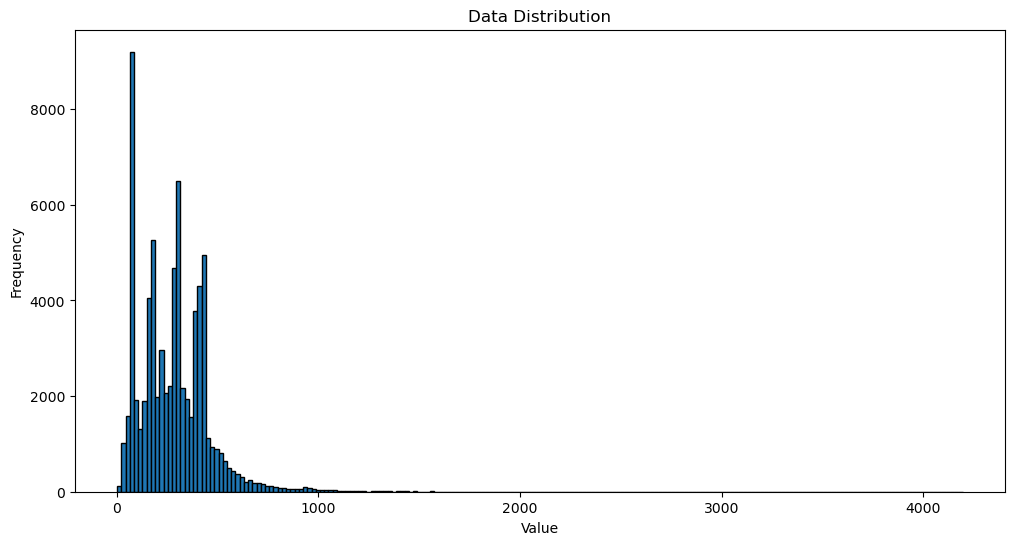

In [30]:
from collections import Counter
import matplotlib.pyplot as plt
frequency = Counter(seq_len_list)
sorted_frequency = dict(sorted(frequency.items()))
print(sorted_frequency)
count1 = len([x for x in seq_len_list if x > 1200])
count2 = len([x for x in seq_len_list if x < 10])

print(count1)
print(count2)

plt.figure(figsize=(12, 6))
plt.hist(seq_len_list, bins=200, edgecolor='black')
plt.title('Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()


In [21]:
#get chem_acts info
BGC_acts={}
for gbk_file,json_file in zip(gbk_paths,json_paths):
    try:
        mibig_BGC=Bgc(gbk_file,json_file)
        BGC_acts[mibig_BGC.bgc_number]=mibig_BGC.get_chem_acts()
    except Exception as e:
        print(gbk_file,{e})

print(BGC_acts)

with open(os.path.join(CURRENT_DIR,"..","data","BGC","chem_acts.pkl"), 'wb') as f:
    pickle.dump(BGC_acts, f)

{'BGC0000001': ['antibacterial'], 'BGC0000002': ['antibacterial'], 'BGC0000003': ['unknown'], 'BGC0000004': ['unknown'], 'BGC0000006': ['unknown'], 'BGC0000007': ['unknown'], 'BGC0000008': ['unknown'], 'BGC0000009': ['unknown'], 'BGC0000010': ['unknown'], 'BGC0000011': ['unknown'], 'BGC0000012': ['unknown'], 'BGC0000013': ['unknown'], 'BGC0000014': ['antifungal'], 'BGC0000016': ['antifungal'], 'BGC0000017': ['neurotoxic'], 'BGC0000018': ['antibacterial'], 'BGC0000019': ['antibacterial'], 'BGC0000020': ['unknown'], 'BGC0000021': ['cytotoxic'], 'BGC0000022': ['unknown'], 'BGC0000023': ['antifungal'], 'BGC0000024': ['antibacterial'], 'BGC0000025': ['anthelmintic'], 'BGC0000026': ['antibacterial'], 'BGC0000027': ['unknown'], 'BGC0000028': ['antibacterial'], 'BGC0000029': ['antibacterial'], 'BGC0000030': ['unknown'], 'BGC0000031': ['antibacterial'], 'BGC0000032': ['antibacterial'], 'BGC0000033': ['antibacterial'], 'BGC0000034': ['antifungal'], 'BGC0000035': ['antibacterial'], 'BGC0000036': 

In [25]:
from collections import Counter
counter = Counter([tuple(value) for value in BGC_acts.values()])
print(counter)

Counter({('unknown',): 1562, ('antibacterial',): 464, ('cytotoxic',): 122, ('antifungal',): 99, ('siderophore',): 42, ('antibacterial', 'unknown'): 30, ('inhibitor',): 25, ('unknown', 'cytotoxic'): 13, ('inhibitor', 'unknown'): 11, ('antiprotozoal',): 10, ('antiviral',): 8, ('antioxidant',): 8, ('anthelmintic',): 7, ('surfactant',): 7, ('antifungal', 'unknown'): 5, ('phytotoxic',): 5, ('signalling',): 4, ('cytotoxic', 'unknown'): 3, ('immunosuppressive',): 3, ('other',): 3, ('herbicidal',): 3, ('signalling', 'unknown'): 3, ('antimalarial',): 3, ('insecticidal',): 3, ('neurotoxic', 'unknown'): 2, ('antibacterial', 'cytotoxic'): 2, ('virulence factor',): 2, ('odorous metabolite',): 2, ('pigment',): 2, ('regulatory',): 2, ('antitubulin',): 2, ('neuroprotective',): 2, ('surfactant', 'unknown'): 2, ('anthelmintic', 'unknown'): 2, ('neurotoxic',): 1, ('antioxidant', 'antifungal', 'unknown'): 1, ('anticancer', 'unknown'): 1, ('anticoccidial',): 1, ('antiplasmodial',): 1, ('fluorescent',): 1, 

In [29]:
#generate original mibig bgc
#if raise error "enzyme" object 
import pandas as pd

columns=["BGC_number","product","biosyn_class","enzyme_list","is_product"]
BGC_data = pd.DataFrame(columns=columns)
for gbk_file,json_file in zip(gbk_paths,json_paths):
    try:
        mibig_BGC=Bgc(gbk_file,json_file)
        bgc_info=mibig_BGC.get_info()
        for info in bgc_info:
            BGC_data.loc[len(BGC_data)] = info
    except Exception as e:
        print(gbk_file,{e})

BGC_data

,BGC_number,product,biosyn_class,enzyme_list,is_product
0,BGC0000001,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1
1,BGC0000001,CC1CC23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)C(C)CC(C)...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1
2,BGC0000002,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,[Polyketide],[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,1
3,BGC0000003,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,[Polyketide],[LPAADLHTALDMLIESRKGFCTQAELEETLRASAEWRGVEKADRD...,1
4,BGC0000004,[H][C@@]12OC=C[C@]1([H])C1=C(O2)C=C(OC)C2=C1OC...,[Polyketide],[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,1
...,...,...,...,...,...
4140,BGC0002736,,[Terpene],[MPESEASFAAMANKYFHTGLPTGEVNNLVLQVASKLVNGNLATIK...,1
4141,BGC0002745,COC1=C(C)C(=O)OC([C@]2(C)O[C@H]2/C(C)=C/C(C)=C...,[Polyketide],[MTFRVIIVGGGVAGLTLASAFEKAGIDYILLECRPAFDVAVGASI...,1
4142,BGC0002746,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C(C)C)N(C)C(=O)[...,[RiPP],[MSSEGISTGDTEDTSVKGDIEGEGSTENRAVLESSDSEVLNLFDP...,1
4143,BGC0002747,CC[C@H](C)[C@@H]1NC(=O)[C@@H]([C@@H](C)CC)N(C)...,[RiPP],[MLTLLPGSYCDVCAEEFSSQCLPHTIPCGHVLCASCCNSIVEKTS...,1


In [3]:
mibig_unique=pd.read_pickle(os.path.join(CURRENT_DIR,"..","data","temp","BGC_data_unique.pkl"))
BGC_enzyme=dict(zip(mibig_unique["BGC_number"],mibig_unique["enzyme_list"]))
with open(os.path.join(CURRENT_DIR,"..","data","BGC","BGC_enzyme.pkl"), 'wb') as f:
    pickle.dump(BGC_enzyme, f)

print(BGC_enzyme["BGC0000001"])

['MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAGDRVLEIGTGSGYSGALLAHLCCPDGQVTSIDISDELVRRAAAIHAERGVTSVDCHVGDGLAGYPAAAPFHRAVSWCAPPRLPRAWTQQVVNGGRIVACLPITALPSTTLIATITVAAGKPRIEALAGGGYAQSTPVAVDDALTVPGRWVDYCDRQPDPSWIGICWRSADDAQHTGARSALGQLLHPGYTDTYRQMEPHWRSWYTWTSALGDPQLSLVSLRNEIRGLGHTTPSSAAVILTDGRVIADRPDSPSLRSLRTWLQRWEHVGRPAPESFARTLVPHDCPDLAGWDLQVGHGSVTTDRQPPRRVDEPRRP', 'MKPPASSVCPVDTSKMGNRSSPARYGRRPRKRCVELSETNLEFVHVVHRRHGHDDPRLGFFFLATAWQGQPVNREPHKCAGLVWTDPAQPPATTIAYTVAALEQIHSGRPFSLDGWAEHSPSATGCGIVDVAWEPPVRRGQREPRHQHDDGGRHGYTVGQPDPCRPLLGCRSTAHPTGCRPRRNVSSWLQLSPRTPGPYAISLMSRER', 'MLGALRIADPAPRTITAPKVETLFATLLIRANHTVTTDELIAELWGENPPRHARTALHVYVSQIRKQIPSPRPGAAVLHTKPQGYQMEVDENLVDAVELQRMHALGRSLLVTDPEAALVPLRRAVGLFRGPVLAGIRNGLVVGNFAEWAEEVRVDCLHAIGRAALATNRHRELIGELVQWVEEHPLHEPLREVLMVALTRAGRRAEALAAYQSTRRVLHEELGLEPGEAMRRLQLAILSADVGLVPAA', 'MTDVQLPAFPMTRTCPHQPPEGYAALRENGPLAQVRLVGDRTAWVVTDHDVARTLLVDPRLSSDRLRPDFPVLVPRMSAAKLVPLVGMDPPVHTQRRRMLIAAFTVHRTQQMRPEIEEIVSARLDAVLQEGPPVDLVPTLALPVPSTVICRLLGVPYADHDFFESQTQRM

### (2)extract BGC without NP structures

In [10]:
#save BGC without NP structures as negative example
no_product=BGC_data[BGC_data['product'] == ' ']
no_product=no_product.drop_duplicates(subset="BGC_number")
no_product["is_product"]=0
no_product.to_pickle(os.path.join(CURRENT_DIR,"..","data","BGC","mibig_negative.pkl"))

In [32]:
#count NP with more than one biosyn_classes
#delete duplicate NP structures
BGC_data_cleaned=BGC_data[BGC_data['product'] != ' ']
BGC_data_cleaned=BGC_data_cleaned.drop_duplicates(subset=["product"])
BGC_data_cleaned=BGC_data_cleaned[BGC_data_cleaned['BGC_number'] != "BGC0002162"]


biosyn_list=BGC_data_cleaned["biosyn_class"].to_list()
print(len(biosyn_list))
multiclass=[biosyn_class for biosyn_class in biosyn_list if len(biosyn_class)>1]
print(len(multiclass))

2841
715


In [30]:
BGC_data.to_pickle(os.path.join(CURRENT_DIR,"..", "data","temp","BGC_original_data.pkl")) 
#all data include BGCs without NP structures

In [31]:
BGC_data['ECFP'] = ""
BGC_data_unique=BGC_data.drop_duplicates(subset='BGC_number', keep='first')
BGC_data_unique.to_pickle(os.path.join(CURRENT_DIR,"..", "data","temp","BGC_data_unique.pkl"))
#one BGC, one row

In [20]:
BGC_data=pd.read_pickle(os.path.join(CURRENT_DIR,"..", "data","temp","BGC_original_data.pkl")) 
additional_BGC = BGC_data[(BGC_data["BGC_number"] == "BGC0000051") | 
                          (BGC_data["BGC_number"] == "BGC0001033") | 
                          (BGC_data["BGC_number"] == "BGC0002095")]
additional_BGC.to_pickle(os.path.join(CURRENT_DIR,"..", "data","temp","additional_BGC.pkl"))


### (3)extract additional data from antismash database(1.0) as negative example

In [7]:
import glob
antismash_path=os.path.join(CURRENT_DIR,"..","data","antismashV1")
antismash_files=[]
for root,dirs,files in os.walk(antismash_path):
    for file in glob.glob(os.path.join(root, '*.gbk')):
        antismash_files.append(os.path.abspath(file))


antismash_01=Bgc(antismash_files[200],database="antismash")
for enzyme in antismash_01.enzyme_list:
    print(enzyme,len(enzyme.aa_sequence),enzyme.domain)

protein_id:AAS42467.1,locus_tag:BCE_3562 277 []
protein_id:AAS42468.1,locus_tag:BCE_3563 171 []
protein_id:AAS42469.1,locus_tag:BCE_3564 323 []
protein_id:AAS42470.1,locus_tag:BCE_3565 359 []
protein_id:AAS42471.1,locus_tag:BCE_3566 310 []
protein_id:AAS42472.1,locus_tag:BCE_3567 477 []
protein_id:AAS42473.1,locus_tag:BCE_3568 92 []
protein_id:AAS42474.1,gene:dhaS,locus_tag:BCE_3569 494 []
protein_id:AAS42475.1,locus_tag:BCE_3570 246 [<__main__.Domain object at 0x000001DB07F3DBB0>]
protein_id:AAS42476.1,locus_tag:BCE_3571 49 []
protein_id:AAS42477.1,locus_tag:BCE_3572 617 []
protein_id:AAS42478.1,locus_tag:BCE_3573 141 []
protein_id:AAS42479.1,locus_tag:BCE_3574 313 []
protein_id:AAS42480.1,locus_tag:BCE_3575 82 []
protein_id:AAS42481.1,locus_tag:BCE_3576 132 []
protein_id:AAS42482.1,locus_tag:BCE_3577 74 []
protein_id:AAS42483.1,locus_tag:BCE_3578 349 []
protein_id:AAS42484.1,gene:moaD,locus_tag:BCE_3579 78 []
protein_id:AAS42485.1,gene:moaE,locus_tag:BCE_3580 154 []
protein_id:AAS424

In [10]:
columns=["BGC_number","product","biosyn_class","enzyme_list","is_product"]
antismash_data = pd.DataFrame(columns=columns)
i=1
for gbk_file in antismash_files:
    if i%500==0:
        print(i)
    try: 
        antismash_BGC=Bgc(gbk_file,database="antismash")
        bgc_info=antismash_BGC.get_info()
        for info in bgc_info:
            antismash_data.loc[len(antismash_data)] = info
    except Exception as e:
        print(gbk_file,{e})
    i+=1
antismash_data
antismash_data.to_pickle(os.path.join(CURRENT_DIR,"..","data","BGC_antismash","BGC_antismash_origin.pkl"))

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
15500
16000
16500
17000
17500
18000
18500
19000
19500
20000
20500
21000
21500
22000


### (4) convert biosynclass in antismash to mibig

In [19]:
antismash_data=pd.read_pickle(os.path.join(CURRENT_DIR,"..","data","BGC_antismash","BGC_antismash_origin.pkl"))
biosyn_set=set(antismash_data['biosyn_class'].to_list())
print(biosyn_set)
biosyn_counts = antismash_data['biosyn_class'].value_counts()
print(biosyn_counts.to_string())


{'nrps-siderophore', 't1pks-siderophore', 'siderophore-transatpks', 't1pks-nrps-butyrolactone', 'resorcinol', 'nrps-ladderane-t2pks', 'otherks-lassopeptide-butyrolactone', 'hserlactone-bacteriocin', 'terpene-siderophore', 'otherks-amglyccycl', 'otherks-t2pks', 'transatpks-bacteriocin-nrps', 'nrps-t1pks-t3pks', 'melanin-nrps', 'otherks-t1pks-PUFA', 'microviridin', 'nrps-hserlactone-arylpolyene', 'hserlactone-lassopeptide', 'terpene-hserlactone', 'nrps-terpene', 'head_to_tail', 't1pks-bacteriocin-nrps', 'ladderane', 't1pks-nrps', 'microcin', 'butyrolactone-nrps-hserlactone', 't1pks-thiopeptide', 'transatpks-nrps-otherks', 'lantipeptide-nrps-t1pks', 'oligosaccharide-t1pks-nrps', 'bacteriocin-nrps-transatpks', 'other', 'lantipeptide-nucleoside-t1pks-aminocoumarin-nrps', 'butyrolactone', 'otherks-terpene', 'butyrolactone-nrps-otherks', 'nrps', 'nrps-ectoine', 'bacteriocin-ectoine', 'glycocin-bacteriocin', 'otherks-lantipeptide-nrps-t1pks-siderophore', 'thiopeptide', 't3pks-bacteriocin', 'ph

In [20]:
convert_df=pd.read_excel(os.path.join(CURRENT_DIR,"..","data","BGC_antismash","class_map.xlsx"))
convert_dict= dict(zip(convert_df['antiSMASH product type'], convert_df['MIBiG classification']))
print(convert_dict)
def convert_class(antismash_class):
    class_list=antismash_class.split("-")
    try:
        class_list=[convert_dict[x] for x in class_list]
    except:
        class_list=["error"]
    return list(set(class_list))

print(convert_class("butyrolactone-t1pks-nrps"))

{'nrps': 'NRP', 't1pks': 'Polyketide', 't2pks': 'Polyketide', 'terpene': 'Terpene', 'lantipeptide': 'RiPP', 'otherks': 'Polyketide', 'transatpks': 'Polyketide', 'indole': 'Alkaloid', 'bacteriocin': 'RiPP', 'amglyccycl': 'Saccharide', 't3pks': 'Polyketide', 'other': 'Other', 'thiopeptide': 'RiPP', 'oligosaccharide': 'Saccharide', 'lassopeptide': 'RiPP', 'nucleoside': 'Other', 'cyanobactin': 'RiPP', 'siderophore': 'Other', 'arylpolyene': 'Polyketide', 'melanin': 'Other', 'butyrolactone': 'Other', 'blactam': 'Other', 'ectoine': 'Other', 'ladderane': 'Other', 'aminocoumarin': 'Other', 'phenazine': 'Other', 'PUFA': 'Polyketide', 'phosphonate': 'Other', 'sactipeptide': 'RiPP', 'linaridin': 'RiPP', 'bottromycin': 'RiPP', 'microviridin': 'RiPP', 'furan': 'Polyketide', 'hserlactone': 'Other', 'head_to_tail': 'RiPP', 'glycocin': 'RiPP', 'proteusin': 'RiPP', 'microcin': 'RiPP', 'pbde': 'Other', 'phosphoglycolipid': 'Other', 'fused': 'Other', 'ppysks': 'Other', 'resorcinol': 'Other'}
['Polyketide'

In [21]:
antismash_data['biosyn_class']=antismash_data['biosyn_class'].apply(convert_class)
biosyn_counts = antismash_data['biosyn_class'].value_counts()
print(biosyn_counts.to_string())

biosyn_class
[Other]                                 5162
[RiPP]                                  4363
[NRP]                                   3942
[Polyketide]                            3211
[Terpene]                               3120
[Polyketide, NRP]                       1375
[NRP, Other]                             165
[Polyketide, Other]                      148
[RiPP, NRP]                              147
[Polyketide, Terpene]                    114
[Polyketide, NRP, Other]                 113
[error]                                  103
[Polyketide, RiPP, NRP]                   44
[Alkaloid]                                42
[RiPP, Other]                             39
[RiPP, Terpene]                           36
[Saccharide]                              30
[Polyketide, RiPP]                        24
[NRP, Terpene]                            22
[Other, Terpene]                          19
[Terpene, Other]                          18
[Polyketide, Saccharide]                  

In [32]:
antismash_data_cleaned=antismash_data[antismash_data["biosyn_class"].apply(lambda x:x!=["error"])]
antismash_data_cleaned
biosyn_class_list=dict(zip(antismash_data_cleaned["BGC_number"],antismash_data_cleaned["biosyn_class"]))
print(biosyn_class_list)
with open(os.path.join(CURRENT_DIR,"..","data","BGC_antismash","antismash_biosynclass.pkl"), 'wb') as f:
    pickle.dump(biosyn_class_list, f)

{'AE000512.1.cluster001': ['RiPP'], 'AE000513.1.cluster001': ['Terpene'], 'AE000513.1.cluster002': ['Terpene'], 'AE000513.1.cluster003': ['Polyketide'], 'AE000513.1.cluster004': ['Polyketide'], 'AE000516.2.cluster001': ['NRP'], 'AE000516.2.cluster002': ['Polyketide'], 'AE000516.2.cluster003': ['RiPP'], 'AE000516.2.cluster004': ['Polyketide', 'NRP'], 'AE000516.2.cluster005': ['Polyketide'], 'AE000516.2.cluster006': ['Polyketide'], 'AE000516.2.cluster007': ['Polyketide'], 'AE000516.2.cluster008': ['Other'], 'AE000516.2.cluster009': ['NRP'], 'AE000516.2.cluster010': ['Other'], 'AE000516.2.cluster011': ['Polyketide', 'NRP'], 'AE000516.2.cluster012': ['Terpene'], 'AE000516.2.cluster013': ['Polyketide'], 'AE000516.2.cluster014': ['Polyketide', 'NRP'], 'AE001437.1.cluster001': ['Other'], 'AE001437.1.cluster002': ['RiPP'], 'AE001437.1.cluster003': ['Polyketide'], 'AE002098.2.cluster001': ['Terpene'], 'AE002098.2.cluster002': ['Terpene'], 'AE002098.2.cluster003': ['Terpene'], 'AE002098.2.cluste

## 3. Load more natural product structures and calculate representations

### (1) Delete BGC without product structure

In [33]:
data_path = os.path.join(CURRENT_DIR,"..", "data", "temp","BGC_original_data.pkl")
origin_data = pd.read_pickle(data_path)
origin_data

,BGC_number,product,biosyn_class,enzyme_list,is_product
0,BGC0000001,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1
1,BGC0000001,CC1CC23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)C(C)CC(C)...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1
2,BGC0000002,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,[Polyketide],[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,1
3,BGC0000003,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,[Polyketide],[LPAADLHTALDMLIESRKGFCTQAELEETLRASAEWRGVEKADRD...,1
4,BGC0000004,[H][C@@]12OC=C[C@]1([H])C1=C(O2)C=C(OC)C2=C1OC...,[Polyketide],[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,1
...,...,...,...,...,...
4140,BGC0002736,,[Terpene],[MPESEASFAAMANKYFHTGLPTGEVNNLVLQVASKLVNGNLATIK...,1
4141,BGC0002745,COC1=C(C)C(=O)OC([C@]2(C)O[C@H]2/C(C)=C/C(C)=C...,[Polyketide],[MTFRVIIVGGGVAGLTLASAFEKAGIDYILLECRPAFDVAVGASI...,1
4142,BGC0002746,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C(C)C)N(C)C(=O)[...,[RiPP],[MSSEGISTGDTEDTSVKGDIEGEGSTENRAVLESSDSEVLNLFDP...,1
4143,BGC0002747,CC[C@H](C)[C@@H]1NC(=O)[C@@H]([C@@H](C)CC)N(C)...,[RiPP],[MLTLLPGSYCDVCAEEFSSQCLPHTIPCGHVLCASCCNSIVEKTS...,1


In [47]:
empty_rows = origin_data[origin_data['product'] == ' ']
print(len(set(origin_data["BGC_number"].to_list()))) #the number of all BGCs

empty_rows=empty_rows["BGC_number"].to_list()
print(len(set(empty_rows))) #the number of BGC without product structure (Note: Some BGCs may have one product with sturcture, while another product without structure)
data_cleaned=origin_data[origin_data['product'] != ' ']
data_cleaned=data_cleaned[data_cleaned['BGC_number'] != "BGC0002162"]

data_cleaned
data_cleaned.to_pickle(os.path.join(CURRENT_DIR,"..", "data","temp","BGC_cleaned.pkl"))

2502
697


### (2)calculate ECFP for natural product from mibig database

In [39]:
smiles_group = data_cleaned.groupby("product")["BGC_number"].apply(list).to_dict() #{smiles:[BGC1,BGC2]}
"""
for group in smiles_group.values():
    if len(group)>1:
        print(group)
"""
smiles_dict = data_cleaned.set_index("product")["BGC_number"].to_dict() #{smiles1:BGC1,smiles2:BGC1,smiles3:BGC2}


smiles_list1 = list(smiles_dict.keys()) #a list of the smiles of all natural products from mibig database

print(len(smiles_list1)) #the number of different natural products (two BGCs may share one NP)
#print(smiles_group)
#print(smiles_dict)
#print(smiles_list1)

2841


In [42]:
# convert smiles to RDKit molecule object
fps1=[] #[(ECFP1,smiles),(ECFP2,smiles)...]
#ECFP is a kind of object
for smiles in smiles_list1:
    try:
        molecule=Chem.MolFromSmiles(smiles)
        fps1.append((AllChem.GetMorganFingerprintAsBitVect(molecule, 3, nBits=1024),smiles))
    except:
        print(smiles,"error")

print(fps1[0]) 
print(data_cleaned["product"][0])


(<rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x000001DE933F0190>, 'CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\\C=C/C(=O)[C@@H](C)C[C@@H](C)C4=O')
CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H](C)C[C@@H](C)C4=O


### (3) Load natural product smiles from coconut database

In [70]:
NP_path=os.path.join(CURRENT_DIR,"..","data","natural_product","COCONUT_DB_absoluteSMILES.smi")
NP_mol=[]
with open(NP_path, 'r') as f: #convert data file from coconut into mol object list(NP_mol)
    i=0
    for line in f:
        if i%200==0:
            print(i,len(NP_mol))
        smiles = line.split()[0]  # 假设每行的第一个元素是 SMILES
        mol = Chem.MolFromSmiles(smiles)
        i+=1
        if mol:
            NP_mol.append(mol)
        
print(len(NP_mol))

0 0
200 198
400 398
600 598
800 798
1000 998
1200 1198
1400 1398
1600 1598


[20:01:47] Explicit valence for atom # 20 C, 6, is greater than permitted
[20:01:47] Explicit valence for atom # 10 C, 6, is greater than permitted


1800 1798
2000 1998
2200 2198
2400 2398
2600 2598
2800 2798
3000 2997


[20:01:48] Explicit valence for atom # 3 B, 4, is greater than permitted


3200 3197
3400 3397
3600 3597
3800 3797
4000 3997
4200 4197
4400 4397
4600 4597
4800 4797
5000 4997
5200 5197
5400 5397
5600 5597
5800 5797
6000 5997
6200 6197
6400 6397
6600 6597
6800 6797
7000 6997
7200 7197
7400 7397
7600 7597
7800 7797
8000 7997
8200 8197
8400 8397
8600 8597
8800 8797
9000 8997
9200 9197
9400 9397
9600 9597
9800 9797
10000 9997
10200 10197
10400 10397
10600 10597
10800 10797
11000 10997
11200 11197
11400 11397
11600 11597
11800 11797
12000 11997
12200 12197
12400 12397
12600 12597
12800 12797
13000 12997
13200 13197
13400 13397
13600 13597
13800 13797
14000 13997
14200 14197
14400 14397
14600 14597
14800 14797
15000 14997
15200 15197
15400 15397
15600 15597
15800 15797
16000 15997
16200 16197
16400 16397
16600 16597
16800 16797
17000 16997
17200 17197
17400 17397
17600 17597
17800 17797
18000 17997
18200 18197
18400 18397
18600 18597
18800 18797
19000 18997
19200 19197
19400 19397
19600 19597
19800 19797
20000 19997
20200 20197
20400 20397
20600 20597
20800 20797
2

...

891800 891331
892000 891531
892200 891729
892400 891928
892600 892126
892800 892326
893000 892525
893200 892723
893400 892922
893600 893122
893800 893321


[20:05:27] Explicit valence for atom # 7 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 9 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 9 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 15 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 4 N, 4, is greater than permitted


894000 893521
894200 893720
894400 893920
894600 894116
894800 894316
895000 894511


[20:05:27] Explicit valence for atom # 20 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 8 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 11 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 37 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 32 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 23 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 8 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 14 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 14 N, 4, is greater than permitted
[20:05:27] Explicit valence for atom # 14 N, 4, is greater than permitted


895200 894711
895400 894911
895068


### (4) calculate ECFP for natural product from coconut database

In [75]:
error_list=[]
fps2=[] #ECFP list for natural product from coconut database
for i,mol in enumerate(NP_mol):
    if i%5000==0:
        print(i,len(error_list))
    try:
        fps2.append((AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=1024),Chem.MolToSmiles(mol)))
    except:
        print("error")
        error_list.append(i)
        continue


0 0
5000 0
10000 0
15000 0
20000 0
25000 0
30000 0
35000 0
40000 0
45000 0
50000 0
55000 0
60000 0
65000 0
70000 0
75000 0
80000 0
85000 0
90000 0
95000 0
100000 0
105000 0
110000 0
115000 0
120000 0
125000 0
130000 0
135000 0
140000 0
145000 0
150000 0
155000 0
160000 0
165000 0
170000 0
175000 0
180000 0
185000 0
190000 0
195000 0
200000 0
205000 0
210000 0
215000 0
220000 0
225000 0
230000 0
235000 0
240000 0
245000 0
250000 0
255000 0
260000 0
265000 0
270000 0
275000 0
280000 0
285000 0
290000 0
295000 0
300000 0
305000 0
310000 0
315000 0
320000 0
325000 0
330000 0
335000 0
340000 0
345000 0
350000 0
355000 0
360000 0
365000 0
370000 0
375000 0
380000 0
385000 0
390000 0
395000 0
400000 0
405000 0
410000 0
415000 0
420000 0
425000 0
430000 0
435000 0
440000 0
445000 0
450000 0
455000 0
460000 0
465000 0
470000 0
475000 0
480000 0
485000 0
490000 0
495000 0
500000 0
505000 0
510000 0
515000 0
520000 0
525000 0
530000 0
535000 0
540000 0
545000 0
550000 0
555000 0
560000 0
565000 0

In [80]:
import pickle

fps1_path=os.path.join(CURRENT_DIR,"..","data","natural_product","BGC_ECFP.pkl")
fps2_path=os.path.join(CURRENT_DIR,"..","data","natural_product","NP_ECFP.pkl")

with open(fps1_path, 'wb') as f:
    pickle.dump(fps1, f)

with open(fps2_path, 'wb') as f:
    pickle.dump(fps2, f)


In [87]:
NP_mol=NP_mol[::10] #降低天然产物的数据量
fps2=fps2[::10]
print(len(NP_mol),len(fps2))

fps2_truncated_path=os.path.join(CURRENT_DIR,"..","data","natural_product","NP_ECFP_truncated.pkl")
with open(fps2_path, 'wb') as f:
    pickle.dump(fps2, f)


KeyboardInterrupt: 

### (5) calculate similarity matrix

In [44]:
fps2=pd.read_pickle(os.path.join(CURRENT_DIR,"..","data","natural_product","NP_ECFP_truncated.pkl"))
similarity_matrix = np.zeros((len(fps1), len(fps2)))

for i, fp1 in enumerate(fps1):
    if i%50==0:
        print(i)
    for j, fp2 in enumerate(fps2):
        similarity_matrix[i, j] = DataStructs.FingerprintSimilarity(fp1[0], fp2[0])

print(similarity_matrix)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
[[0.1292517  0.125      0.09565217 ... 0.06060606 0.11382114 0.10204082]
 [0.1292517  0.125      0.09565217 ... 0.06060606 0.11382114 0.10204082]
 [0.16205534 0.11507937 0.10917031 ... 0.0787037  0.11814346 0.12840467]
 ...
 [0.11111111 0.12142857 0.14035088 ... 0.06862745 0.09302326 0.09210526]
 [0.09569378 0.09090909 0.07386364 ... 0.05660377 0.10497238 0.13065327]
 [0.08374384 0.078125   0.07784431 ... 0.03921569 0.10404624 0.11917098]]


In [45]:
print(similarity_matrix.shape)
print(len(smiles_list1))
similarity_path=os.path.join(CURRENT_DIR,"..","data","natural_product","similaity_matrix.pkl")

with open(similarity_path, 'wb') as f:
    pickle.dump(similarity_matrix, f)



(2841, 89507)
2841


### (6) map ECFP

In [2]:
data_cleaned=pd.read_pickle(os.path.join(CURRENT_DIR,"..","data","temp","BGC_cleaned.pkl"))
data_cleaned["ECFP_tensor"]=""
data_cleaned

,BGC_number,product,biosyn_class,enzyme_list,is_product,ECFP_tensor
0,BGC0000001,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1,
1,BGC0000001,CC1CC23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)C(C)CC(C)...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1,
2,BGC0000002,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,[Polyketide],[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,1,
3,BGC0000003,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,[Polyketide],[LPAADLHTALDMLIESRKGFCTQAELEETLRASAEWRGVEKADRD...,1,
4,BGC0000004,[H][C@@]12OC=C[C@]1([H])C1=C(O2)C=C(OC)C2=C1OC...,[Polyketide],[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,1,
...,...,...,...,...,...,...
4136,BGC0002735,CC(C)[C@H](O)[C@H](NC(=O)[C@@](C)(O)C12CCC([C@...,"[Polyketide, NRP]",[IPLSFAQRRLWFVDRFEGPSPTYNGAFALRLTGELDTGALQAALR...,1,
4137,BGC0002735,CC(C)[C@@H]1OC(=O)[C@H]([C@@H](C)O)NC(=O)[C@@H...,"[Polyketide, NRP]",[IPLSFAQRRLWFVDRFEGPSPTYNGAFALRLTGELDTGALQAALR...,1,
4141,BGC0002745,COC1=C(C)C(=O)OC([C@]2(C)O[C@H]2/C(C)=C/C(C)=C...,[Polyketide],[MTFRVIIVGGGVAGLTLASAFEKAGIDYILLECRPAFDVAVGASI...,1,
4142,BGC0002746,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C(C)C)N(C)C(=O)[...,[RiPP],[MSSEGISTGDTEDTSVKGDIEGEGSTENRAVLESSDSEVLNLFDP...,1,


In [4]:
fps1_path=os.path.join(CURRENT_DIR,"..","data","natural_product","BGC_ECFP.pkl") #ECFP and smiles of products from BGC
fps1=pd.read_pickle(fps1_path)
fps1_dict={fps[1]:fps[0] for fps in fps1}
def obj_to_tensor(obj):
    fp_array = np.zeros((1,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(obj, fp_array)
    return torch.tensor(fp_array)


In [17]:
data_cleaned["ECFP_tensor"]=data_cleaned["product"].map(fps1_dict)
data_cleaned["ECFP_tensor"]=data_cleaned["ECFP_tensor"].apply(obj_to_tensor)
data_cleaned.to_pickle(os.path.join(CURRENT_DIR,"..","data","BGC","BGC_cleaned_ECFP.pkl"))
data_cleaned
#data_cleaned were saved to data_preprocess.py

,BGC_number,product,biosyn_class,enzyme_list,is_product,ECFP_tensor
0,BGC0000001,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1,"[tensor(0, dtype=torch.int32), tensor(0, dtype..."
1,BGC0000001,CC1CC23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)C(C)CC(C)...,[Polyketide],[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,1,"[tensor(0, dtype=torch.int32), tensor(0, dtype..."
2,BGC0000002,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,[Polyketide],[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,1,"[tensor(0, dtype=torch.int32), tensor(1, dtype..."
3,BGC0000003,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,[Polyketide],[LPAADLHTALDMLIESRKGFCTQAELEETLRASAEWRGVEKADRD...,1,"[tensor(0, dtype=torch.int32), tensor(1, dtype..."
4,BGC0000004,[H][C@@]12OC=C[C@]1([H])C1=C(O2)C=C(OC)C2=C1OC...,[Polyketide],[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,1,"[tensor(0, dtype=torch.int32), tensor(0, dtype..."
...,...,...,...,...,...,...
4136,BGC0002735,CC(C)[C@H](O)[C@H](NC(=O)[C@@](C)(O)C12CCC([C@...,"[Polyketide, NRP]",[IPLSFAQRRLWFVDRFEGPSPTYNGAFALRLTGELDTGALQAALR...,1,"[tensor(0, dtype=torch.int32), tensor(1, dtype..."
4137,BGC0002735,CC(C)[C@@H]1OC(=O)[C@H]([C@@H](C)O)NC(=O)[C@@H...,"[Polyketide, NRP]",[IPLSFAQRRLWFVDRFEGPSPTYNGAFALRLTGELDTGALQAALR...,1,"[tensor(0, dtype=torch.int32), tensor(1, dtype..."
4141,BGC0002745,COC1=C(C)C(=O)OC([C@]2(C)O[C@H]2/C(C)=C/C(C)=C...,[Polyketide],[MTFRVIIVGGGVAGLTLASAFEKAGIDYILLECRPAFDVAVGASI...,1,"[tensor(0, dtype=torch.int32), tensor(0, dtype..."
4142,BGC0002746,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C(C)C)N(C)C(=O)[...,[RiPP],[MSSEGISTGDTEDTSVKGDIEGEGSTENRAVLESSDSEVLNLFDP...,1,"[tensor(0, dtype=torch.int32), tensor(1, dtype..."


natural product ECFPs (fps1,fps2), smiles, BGC data and some functions for preprocess were saved to data_preprocess.py

# 计算BGC类型

In [ ]:
import os
filepath = os.path.join(CURRENT_DIR,"..", "data", "mibig_json_3.1")
items = os.listdir(filepath)

def get_complete(filename):
    import json
    with open(filename, "r") as file:
        json_text = file.read()
    data = json.loads(json_text)
    result = data["cluster"]["loci"]["completeness"]
    return result

def get_structure(filename):
    n=0
    import json
    with open(filename, "r") as file:
        json_text = file.read()
    data = json.loads(json_text)
    compounds = data["cluster"]["compounds"]
    try:
        chem_struct=compounds[0]["chem_struct"]
    except:
        n=1
    return n

complete_count={}
count=0
for file in items:
    filename=filepath+"\\"+file
    result=get_complete(filename)
    count+=get_structure(filename)
    if result not in complete_count:
        complete_count[result]=1
    else:
        complete_count[result]+=1

print(complete_count)
print(count)